In [12]:
import sys
import os

sys.path.append(os.path.abspath(".."))

In [13]:
import pandas as pd

df = pd.read_csv("../data/raw/tweets.csv", encoding='latin-1', header=None)
df = df.iloc[:200]

texts = df.iloc[:, 5]
texts.head()

0    @switchfoot http://twitpic.com/2y1zl - Awww, t...
1    is upset that he can't update his Facebook by ...
2    @Kenichan I dived many times for the ball. Man...
3      my whole body feels itchy and like its on fire 
4    @nationwideclass no, it's not behaving at all....
Name: 5, dtype: str

In [14]:
from src.preprocessing import clean_text

cleaned = texts.apply(clean_text)
cleaned.head()

0    switchfoot   awww thats a bummer  you shoulda ...
1    is upset that he cant update his facebook by t...
2    kenichan i dived many times for the ball manag...
3      my whole body feels itchy and like its on fire 
4    nationwideclass no its not behaving at all im ...
Name: 5, dtype: str

In [15]:
from src.embedding import get_tfidf

tfidf_embeddings = get_tfidf(cleaned)
print(tfidf_embeddings.shape)

(200, 901)


In [16]:
from src.embedding import get_bert

bert_embeddings = get_bert(cleaned.tolist())
print(len(bert_embeddings))

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 7316.43it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


200


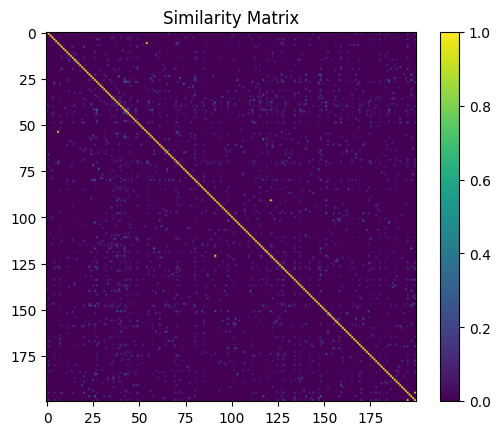

In [17]:
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt

sim = cosine_similarity(tfidf_embeddings)

plt.imshow(sim)
plt.title("Similarity Matrix")
plt.colorbar()
plt.show()

In [18]:
from src.graph_builder import build_graph
from src.community import detect_communities

G = build_graph(sim, cleaned.tolist(), 0.3)
partition = detect_communities(G)

In [ ]:
from collections import defaultdict

G, partition, texts = run_pipeline()

communities = defaultdict(list)

for node, comm in partition.items():
    communities[comm].append(texts[node])

print("\nTotal communities:", len(communities))

for comm, members in communities.items():
    print(f"\nCommunity {comm} ({len(members)} nodes):")
    for m in members[:3]:
        print("-", m[:80])


Community 0 (1 nodes):
- @switchfoot http://twitpic.com/2y1zl - Awww, that's a bummer.  You shoulda got David Carr of Third Day to do it. ;D

Community 1 (1 nodes):
- is upset that he can't update his Facebook by texting it... and might cry as a result  School today also. Blah!

Community 2 (1 nodes):
- @Kenichan I dived many times for the ball. Managed to save 50%  The rest go out of bounds

Community 3 (1 nodes):
- my whole body feels itchy and like its on fire 

Community 4 (1 nodes):
- @nationwideclass no, it's not behaving at all. i'm mad. why am i here? because I can't see you all over there. 

Community 5 (1 nodes):
- @Kwesidei not the whole crew 

Community 6 (2 nodes):
- Need a hug 
- I need a hug 

Community 7 (1 nodes):
- @LOLTrish hey  long time no see! Yes.. Rains a bit ,only a bit  LOL , I'm fine thanks , how's you ?

Community 8 (1 nodes):
- @Tatiana_K nope they didn't have it 

Community 9 (1 nodes):
- @twittera que me muera ? 

Community 10 (1 nodes):
- spring break i

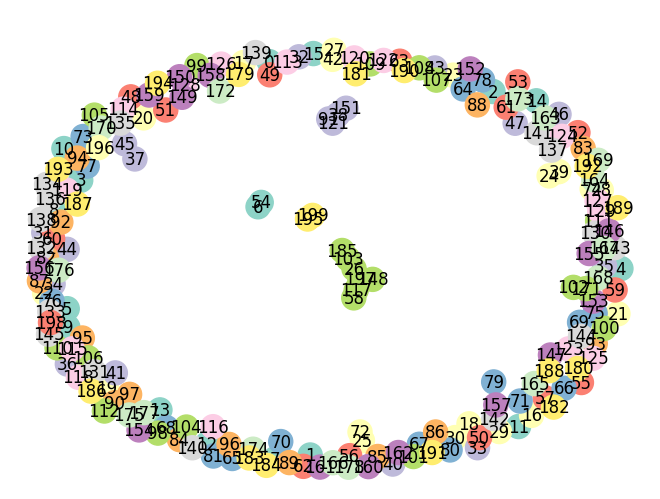

In [20]:
from src.visualize import draw_graph

draw_graph(G, partition)